# Anomaly detection with Linear Regression
In this laboratory, we will use a Linear Regression to predict the average Inter Arrival Time (IAT) of packets and to spot anomalies. In particular, we make our model learning the average IAT of benign flows and we predict the IAT of new traffic. If the squared error between the prediction and the actual value is higher than a threshold, we label the sample (flow) as an anomaly. After that, we compute the accuracy scores.
We will train a linear regression model on a dataset of benign traffic, and then we will test the trained model with DDoS attack traffic.

We will use a dataset of benign and various DDoS attacks from the CIC-DDoS2019 dataset (https://www.unb.ca/cic/datasets/ddos-2019.html).
The network traffic has been previously pre-processed in a way that packets are grouped in bi-directional traffic flows using the 5-tuple (source IP, destination IP, source Port, destination Port, protocol). Each flow is represented with 21 packet-header features computed from max 1000 packets:

| Feature nr.         | Feature Name |
|---------------------|---------------------|
| 00 | timestamp (mean IAT) | 
| 01 | packet_length (mean)| 
| 02 | IP_flags_df (sum) |
| 03 | IP_flags_mf (sum) |
| 04 | IP_flags_rb (sum) | 
| 05 | IP_frag_off (sum) |
| 06 | protocols (mean) |
| 07 | TCP_length (mean) |
| 08 | TCP_flags_ack (sum) |
| 09 | TCP_flags_cwr (sum) |
| 10 | TCP_flags_ece (sum) |
| 11 | TCP_flags_fin (sum) |
| 12 | TCP_flags_push (sum) |
| 13 | TCP_flags_res (sum) |
| 14 | TCP_flags_reset (sum) |
| 15 | TCP_flags_syn (sum) |
| 16 | TCP_flags_urg (sum) |
| 17 | TCP_window_size (mean) |
| 18 | UDP_length (mean) |
| 19 | ICMP_type (mean) |
| 20 | Packets (counter)|

In [ ]:
# Author: Roberto Doriguzzi-Corin
# Project: Course on Network Intrusion and Anomaly Detection with Machine Learning
#
# Licensed under the Apache License, Version 2.0 (the "License");
# you may not use this file except in compliance with the License.
# You may obtain a copy of the License at
#
#   http://www.apache.org/licenses/LICENSE-2.0
#
# Unless required by applicable law or agreed to in writing, software
# distributed under the License is distributed on an "AS IS" BASIS,
# WITHOUT WARRANTIES OR CONDITIONS OF ANY KIND, either express or implied.
# See the License for the specific language governing permissions and
# limitations under the License.

import os
import numpy as np
import glob
import h5py
import sys
import copy
import argparse
from sklearn.metrics import classification_report, mean_squared_error
import logging
import seaborn as sns
from util_functions import *
from IPython.display import Image, display
from sklearn.tree import export_graphviz
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures

OUTPUT_FILE = "./rf_tree"
BENIGN_FOLDER = "./DOS2019/benign"
ATTACK_DNS = "./DOS2019/dns"
ATTACK_WEBDDOS = "./DOS2019/webddos"

from matplotlib import pyplot as plt
plt.rcParams.update({'figure.figsize': (12.0, 8.0)})
plt.rcParams.update({'font.size': 14})

SEED=1
feature_names = get_feature_names()

X_train_benign, y_train_benign = load_dataset(BENIGN_FOLDER + "/*" + '-train.hdf5')
X_val_benign, y_val_benign = load_dataset(BENIGN_FOLDER + "/*" + '-val.hdf5')
X_test_dns, y_test_dns = load_dataset(ATTACK_DNS + "/*" + '-test.hdf5')
X_test_webddos, y_test_webddos = load_dataset(ATTACK_WEBDDOS + "/*" + '-test.hdf5')

X_test_attack = np.concatenate((X_test_dns,X_test_webddos))
y_test_attack = np.concatenate((y_test_dns,y_test_webddos))

# Dataset for regression problems
In the next cell, we modify the dataset to make it suitable for regression problems. In particular, we will use one of the features as target value (e.g, the average inter-arrival time of packets, or the average packet size). The selected feature is also removed from the samples, as it is used as label for training.

In [79]:
Y_INDEX = 0 # index of the feature used as value to predict. 0 = average IAT, 1 = average packet size of the flow

y_reg_train_benign = X_train_benign[:,Y_INDEX]
X_reg_train_benign = np.delete(X_train_benign, Y_INDEX, axis=1)

y_reg_val_benign = X_val_benign[:,Y_INDEX]
X_reg_val_benign = np.delete(X_val_benign, Y_INDEX, axis=1)

y_reg_test_attack = X_test_attack[:,Y_INDEX]
X_reg_test_attack = np.delete(X_test_attack, Y_INDEX, axis=1)

# Training the Linear Regressor
We train the Linear Regressor to predict the average packet size of the benign flows. 

In [80]:
lr = LinearRegression()
lr.fit(X_reg_train_benign, y_reg_train_benign)

print("Bias: ", lr.intercept_) # bias
print("Weights: ", lr.coef_) # weights

Bias:  0.007094210608050371
Weights:  [ 1.96284280e-03 -3.00779578e-04 -1.13841228e-16  7.51352106e-17
  3.68628739e-18 -1.29042004e-04 -2.16109385e-03  4.01823429e-04
 -1.04083409e-17 -1.47451495e-17  1.21781535e-02 -1.81006853e-03
  0.00000000e+00 -9.55091254e-03  3.84902402e-02  0.00000000e+00
  1.19224805e-06  1.43483613e-03  0.00000000e+00  1.21196278e-04]


# Validating the Linear Regressor with benign traffic
Now the Linear regressor is trained. We can use it to make predictions on unseen data. We first start with the validation set of benign traffic, which allows us to understand what is the average error of the prediction on it. 
This MSE and the standard deviation of the squared errors will be used to define the threshold for anomaly detection. We add the standard deviation to minimise false positives.

MSE measures on the benign validation set:  0.022446710292665876
Standard deviation of squared errors:  0.1116383989598679
Anomaly Threshold:  0.13408510925253378


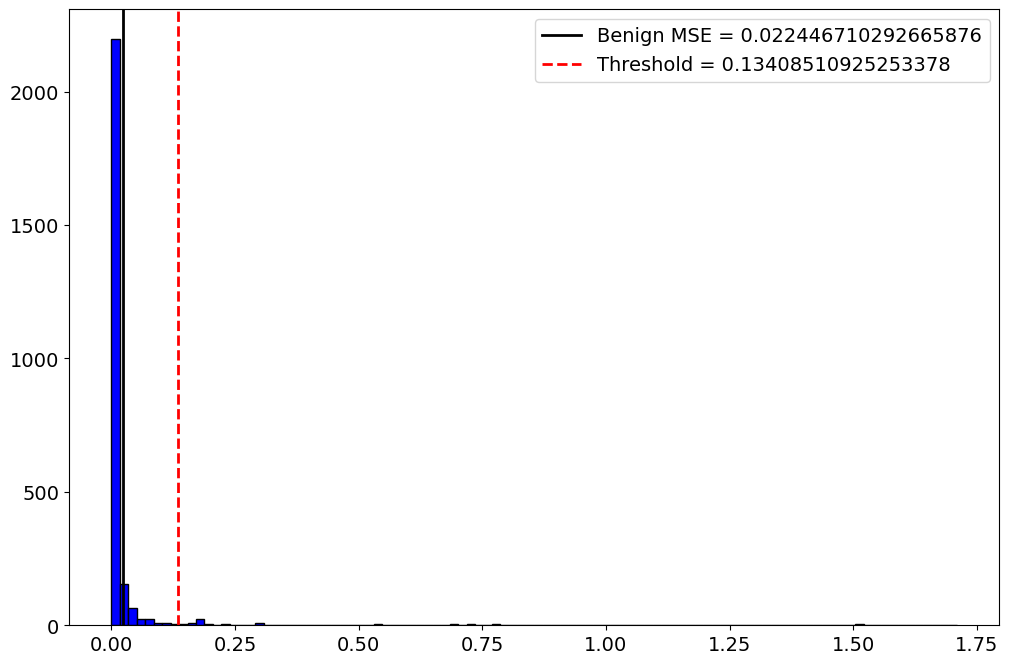

In [81]:
y_reg_pred_benign = lr.predict(X_reg_val_benign)

benign_mse = mean_squared_error(y_reg_val_benign,y_reg_pred_benign)
print("MSE measures on the benign validation set: ", benign_mse)

benign_squared_errors = ((y_reg_val_benign-y_reg_pred_benign)**2)
print("Standard deviation of squared errors: ", benign_squared_errors.std())

# Define the threshold as the MSE+std_dev
attack_threshold = benign_mse + benign_squared_errors.std()
print ("Anomaly Threshold: ", attack_threshold)

# Plot the squared error distribution
plt.hist(benign_squared_errors, color = 'blue', edgecolor = 'black',bins=100)
 # your chosen x position
plt.axvline(x=benign_mse, color='black', linestyle='-', linewidth=2, label=f"Benign MSE = {benign_mse}")
plt.axvline(x=attack_threshold, color='red', linestyle='--', linewidth=2, label=f"Threshold = {attack_threshold}")
plt.legend()
plt.show()

# MSE and threshold on the validation set
All the data points that produce a squared error above the threshold is considered an anomaly.

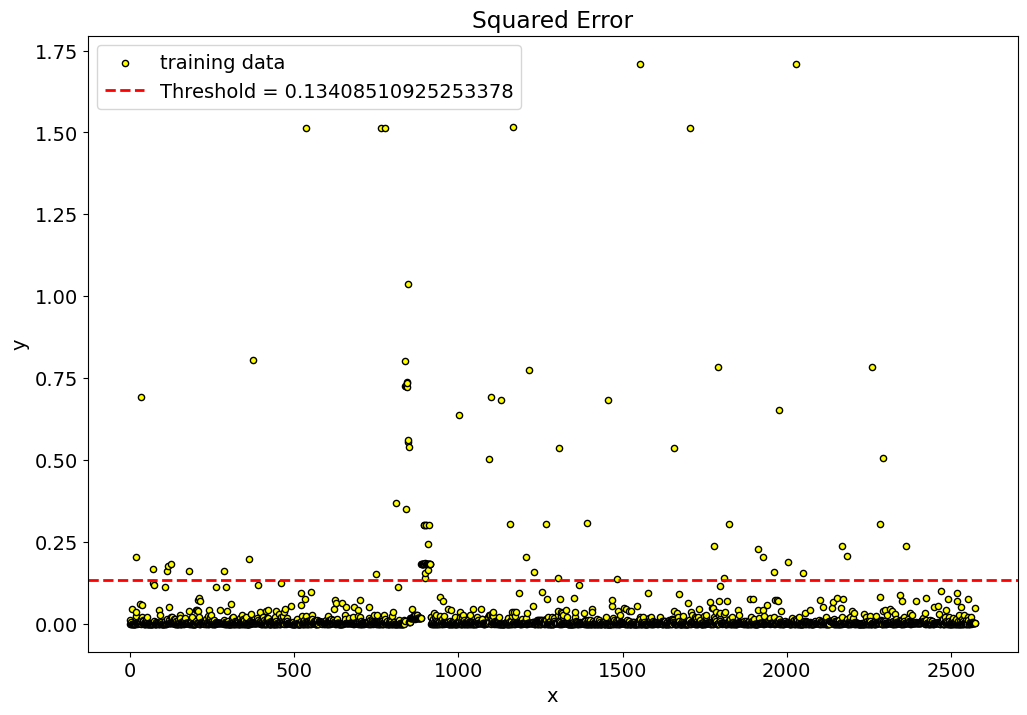

In [82]:
mse_training_val = (y_reg_val_benign - y_reg_pred_benign) ** 2

plt.figure()
plt.scatter(range(len(mse_training_val)), mse_training_val, s=20, edgecolor="black", c="yellow", label="training data")
plt.axhline(y=attack_threshold, color='r', linestyle='--', linewidth=2, label=f"Threshold = {attack_threshold}") 
plt.xlabel("x")
plt.ylabel("y")
plt.title("Squared Error")
plt.legend()
plt.show()

# Testing the Linear Regressor with DDoS attack traffic
We test the Linear regressor on attack data samples. These samples have been generated by using DDoS attacks from the CIC-DDoS2019 dataset. We first measure the MSE and then we print the accuracy metrics obtained with the anomaly threshold computed in the previous step.

In [83]:
y_reg_pred_attack = lr.predict(X_reg_test_attack)

attack_mse = mean_squared_error(y_reg_test_attack,y_reg_pred_attack)
print("MSE measures on the attack test set: ", attack_mse)

MSE measures on the attack test set:  7.814886220018394


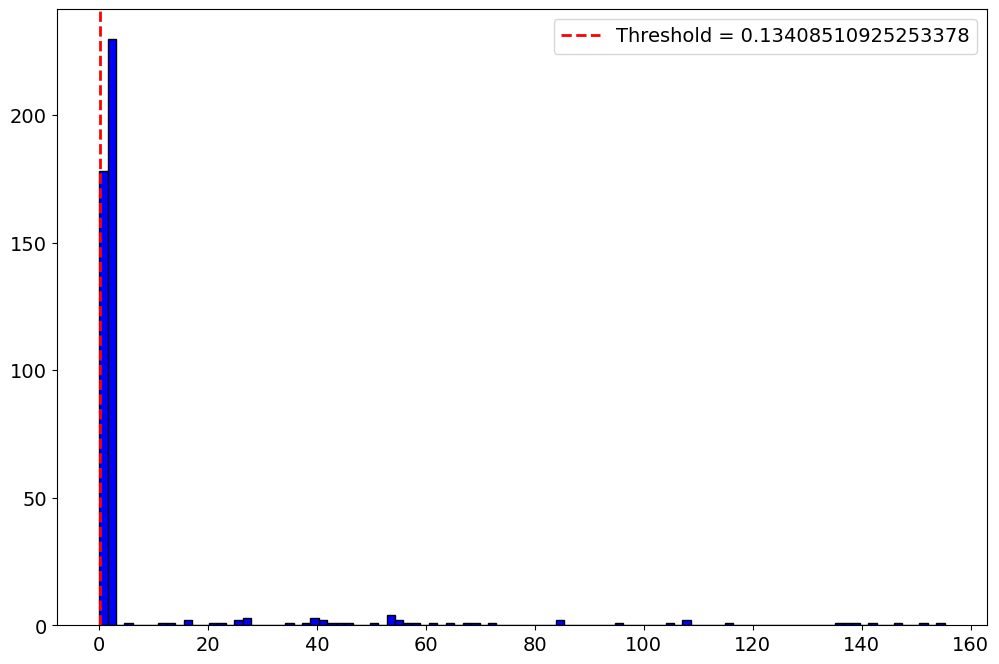

In [84]:
attack_squared_errors = ((y_reg_test_attack-y_reg_pred_attack)**2)

# Plot the squared error distribution
plt.hist(attack_squared_errors, color = 'blue', edgecolor = 'black',bins=100)

x_value = attack_threshold  # your chosen x position
plt.axvline(x=x_value, color='red', linestyle='--', linewidth=2, label=f"Threshold = {x_value}")
plt.legend()
plt.show()

# Check the threshold
Let's reduce the range of the x-axis to better understand the impact of the threshold on the attack traffic classification.

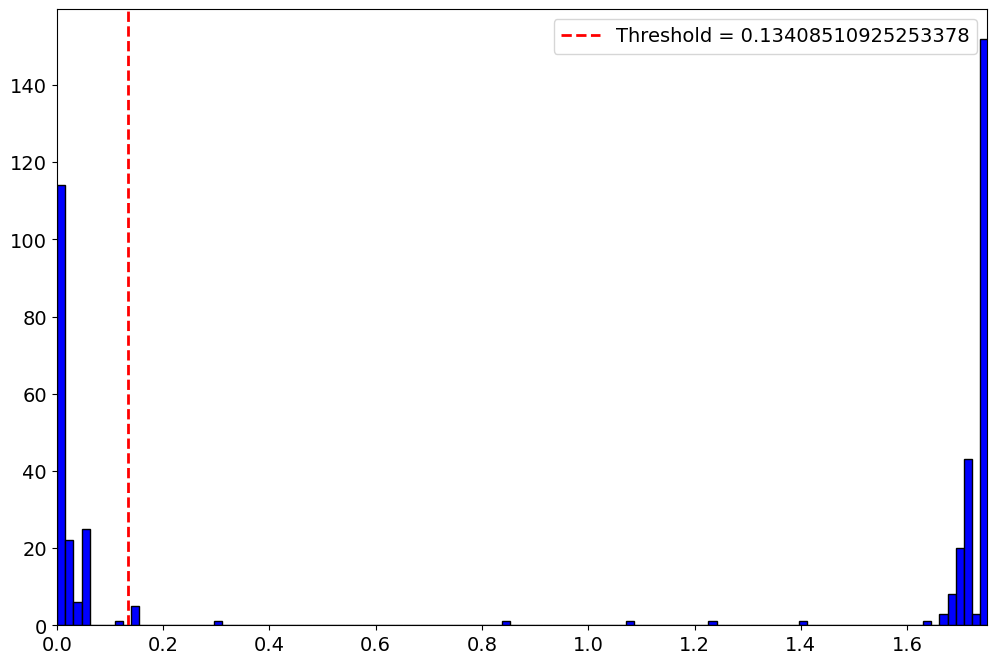

In [85]:
attack_squared_errors = ((y_reg_test_attack-y_reg_pred_attack)**2)

# Plot the squared error distribution
#plt.hist(attack_squared_errors, color = 'blue', edgecolor = 'black',bins=100)
plt.xlim(0, 1.75) 
plt.hist(attack_squared_errors, color = 'blue', edgecolor = 'black',bins=10000)

x_value = attack_threshold  # your chosen x position
plt.axvline(x=x_value, color='red', linestyle='--', linewidth=2, label=f"Threshold = {x_value}")
plt.legend()
plt.show()

# Using the threshold to spot anomalous samples
All the data points that produce a squared error above the threshold is considered an anomaly. Note that the attack traffic is obtained by merging a test set with a DNS DDoS attack (297 samples), with a test set with a WebDDoS attack (161 samples). This explains the sudden change in the squared errors after sample 297.

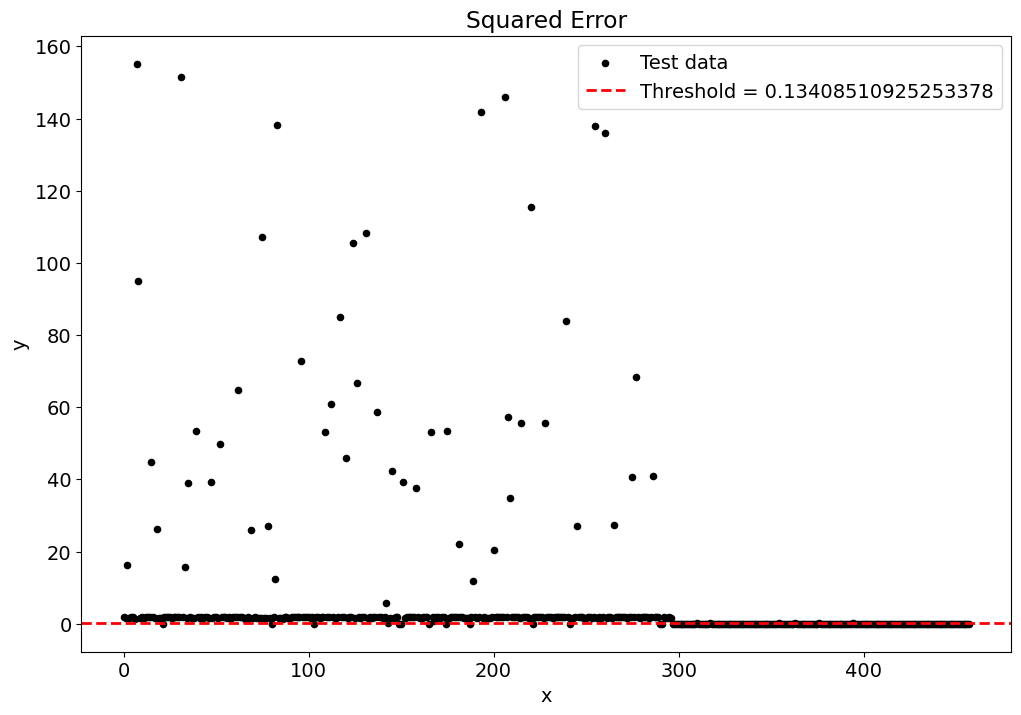

In [88]:
mse_training_test = (y_reg_test_attack - y_reg_pred_attack) ** 2

plt.figure()
plt.scatter(range(len(mse_training_test)), mse_training_test, s=20, edgecolor="black", c="black", label="Test data")
plt.axhline(y=attack_threshold, color='r', linestyle='--', linewidth=2, label=f"Threshold = {attack_threshold}") 
plt.xlabel("x")
plt.ylabel("y")
plt.title("Squared Error")
plt.legend()
plt.show()

# Check the threshold
Let's reduce the range of the y-axis to better understand the impact of the threshold on the attack traffic classification.

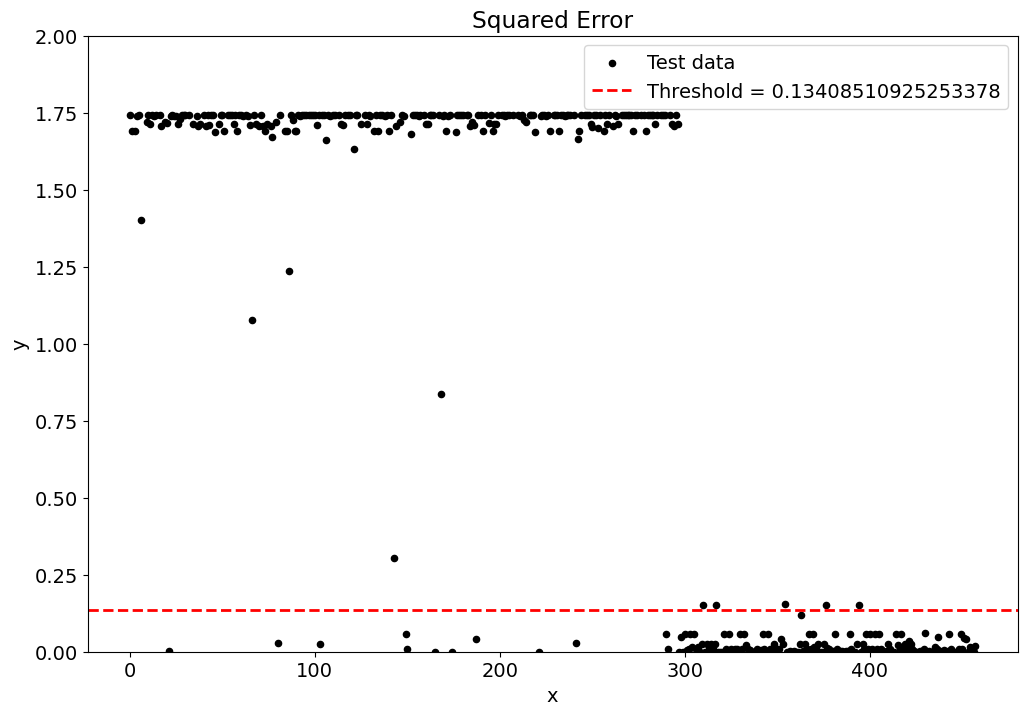

In [89]:
mse_training_test = (y_reg_test_attack - y_reg_pred_attack) ** 2

plt.figure()
plt.scatter(range(len(mse_training_test)), mse_training_test, s=20, edgecolor="black", c="black", label="Test data")
plt.axhline(y=attack_threshold, color='r', linestyle='--', linewidth=2, label=f"Threshold = {attack_threshold}") 
plt.xlabel("x")
plt.ylabel("y")
plt.title("Squared Error")
plt.ylim(0, 2)   # <-- set y-axis range here
plt.legend()
plt.show()

# Accuracy metrics
We compute the accuracy metrics on the test sets of benign and attack traffic using the threshold computed above.

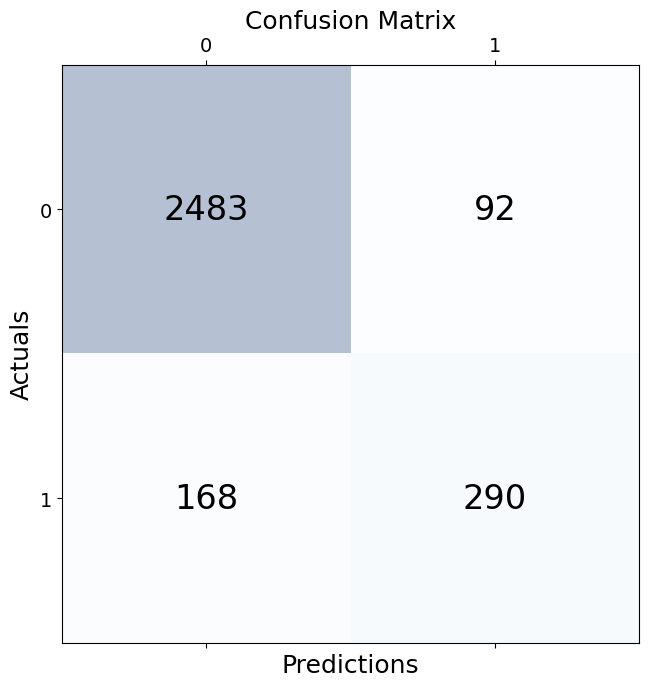

In [56]:
import seaborn as sn
import pandas as pd

tn_fp = [True if err < attack_threshold else False for err in benign_squared_errors]
tp_fn = [True if err > attack_threshold else False for err in attack_squared_errors]

tn = sum(tn_fp)
tp = sum(tp_fn)
fp = len(tn_fp) - tn
fn = len(tp_fn) - tp

# Display the confusion matrix
conf_matrix = np.array([[tn,fp],[fn,tp]])

fig, ax = plt.subplots(figsize=(7.5, 7.5))
ax.matshow(conf_matrix, cmap=plt.cm.Blues, alpha=0.3)
for i in range(conf_matrix.shape[0]):
    for j in range(conf_matrix.shape[1]):
        ax.text(x=j, y=i,s=conf_matrix[i, j], va='center', ha='center', size='xx-large')
 
plt.xlabel('Predictions', fontsize=18)
plt.ylabel('Actuals', fontsize=18)
plt.title('Confusion Matrix', fontsize=18)
plt.show()

In [57]:
accuracy = (tp+tn)/(tp+tn+fp+fn)
tpr = tp/(tp+fn) # recall
ppv = tp/(tp+fp) # precision
fpr = fp/(fp+tn) # false positive rate
fnr = fn/(fn+tp) # false negative rate
f1_score = 2*(tpr*ppv)/(tpr+ppv)


print ("Accuracy: ", accuracy)
print ("F1 Score: ", f1_score)
print ("FPR: ", fpr)
print ("FNR: ", fnr)

Accuracy:  0.9142762940982525
F1 Score:  0.6904761904761905
FPR:  0.03572815533980583
FNR:  0.36681222707423583


# Linear regression with polynomial features
You can use a linear model to fit nonlinear data. A simple way to do this is to add powers of each feature as new features, then train a linear model on this extended set of features. This technique is called Polynomial Regression. 

In [58]:
# X_poly now contains the original feature of X plus the square of this feature
poly_features = PolynomialFeatures(degree=2, include_bias=False)
X_poly_train = poly_features.fit_transform(X_reg_train_benign)

lr = LinearRegression() 
lr.fit(X_poly_train, y_reg_train_benign)
print(lr.intercept_, lr.coef_) # print bias and weights

-57.02179754395535 [ 1.16252311e+00 -4.56717529e-02 -8.39312985e-09  1.00998807e-08
 -1.76629629e-08  1.14158650e-01 -1.16951730e+00  5.05157889e-01
  6.20158559e-10  5.23348294e-11  4.11699257e-02 -6.95397387e-01
 -2.04217181e-08  7.56910697e-03 -1.21556319e-03 -7.21979771e-09
  4.80439509e-04 -9.11166174e-03  4.60725713e-09 -3.97141284e-01
 -1.93280362e-04  5.73387494e-05  1.22145155e-08 -6.52362007e-09
  3.90961141e-10 -1.98726052e-03  3.84301570e-04 -1.19768320e-02
 -8.59407394e-09 -1.34715520e-09  3.00122466e-04  3.71776821e-05
 -6.60118021e-10 -1.18159414e-02 -4.38000427e-03  5.66351480e-12
 -1.51392676e-07 -9.10044792e-02  5.26590924e-12  1.19171311e-02
  2.12221450e-06  3.16224824e-12  5.03987824e-12  6.88147456e-13
  7.21190169e-05 -5.44404573e-05 -7.10674729e-06 -1.37440059e-12
  5.33378897e-13 -9.37006378e-04  5.06029832e-06  2.12663220e-12
  1.46112497e-03 -7.83262282e-05  1.98041583e-12  1.16396698e-07
 -1.41738733e-03 -6.99995617e-13  2.51377429e-06  3.83580667e-12
 -4.49

# Validating the Linear Regressor with polynomial features using the benign traffic
We can use the new regressor to make predictions on the validation set. Also in this case, we use the results of this test to set the anomaly threshold

In [59]:
X_poly_val = poly_features.fit_transform(X_reg_val_benign)
y_reg_pred_benign = lr.predict(X_poly_val)

benign_mse = mean_squared_error(y_reg_val_benign,y_reg_pred_benign)
print("MSE measured on the benign validation set: ", benign_mse)

benign_squared_errors = ((y_reg_val_benign-y_reg_pred_benign)**2)
print("Standard deviation of squared errors: ", benign_squared_errors.std())

# Define the threshold as the MSE+std_dev
attack_threshold = benign_mse + benign_squared_errors.std()
print ("Anomaly Threshold: ", attack_threshold)

MSE measured on the benign validation set:  0.030698098944451288
Standard deviation of squared errors:  0.5016911083962186
Anomaly Threshold:  0.5323892073406699


# Testing the Linear Regressor with DDoS attack traffic
We test the Linear regressor on attack data samples. These samples have been generated by using DDoS attacks from the CIC-DDoS2019 dataset. We first measure the MSE and then we print the accuracy metrics obtained with the anomaly threshold computed in the previous step.

In [60]:
X_poly_test_attack = poly_features.fit_transform(X_reg_test_attack)
y_reg_pred_attack = lr.predict(X_poly_test_attack)
print (y_reg_pred_attack)

attack_mse = mean_squared_error(y_reg_test_attack,y_reg_pred_attack)
print("MSE measured on the benign test set: ", attack_mse)

[ 9.12474987e+01  6.84532569e+01  3.73676251e+01  6.84532569e+01
  9.12474987e+01  9.12474987e+01  2.85823700e+00  3.33481627e+06
  1.57374381e+06  8.80480094e+01  9.12474987e+01  7.23669067e+01
  9.12474987e+01  9.12474987e+01  9.12474987e+01  3.41279488e+05
  9.12474987e+01  7.23669067e+01  3.49142238e+04  8.80480094e+01
  5.57512529e+01  1.31343907e-01  9.12474987e+01  9.12474987e+01
  9.12474987e+01  9.12474987e+01  7.23669067e+01  8.11232972e+01
  9.12474987e+01  9.12474987e+01  9.12474987e+01  3.21799291e+06
  9.12474987e+01  3.90162460e+01  7.23669067e+01  2.29011888e+05
  9.12474987e+01  7.23669067e+01  7.23669067e+01  5.19757991e+05
  9.12474987e+01  7.23669067e+01  9.12474987e+01  7.23669067e+01
  9.12474987e+01  9.12474987e+01  6.84532569e+01  2.33839297e+05
  7.23669067e+01  9.12474987e+01  9.12474987e+01  6.84532569e+01
  4.45567393e+05  9.12474987e+01  9.12474987e+01  9.12474987e+01
  7.23669067e+01  9.12474987e+01  6.84532569e+01  9.12474987e+01
  9.12474987e+01  9.12474

# Accuracy metrics
We compute the accuracy metrics on the test sets of benign and attack traffic using the threshold computed above.

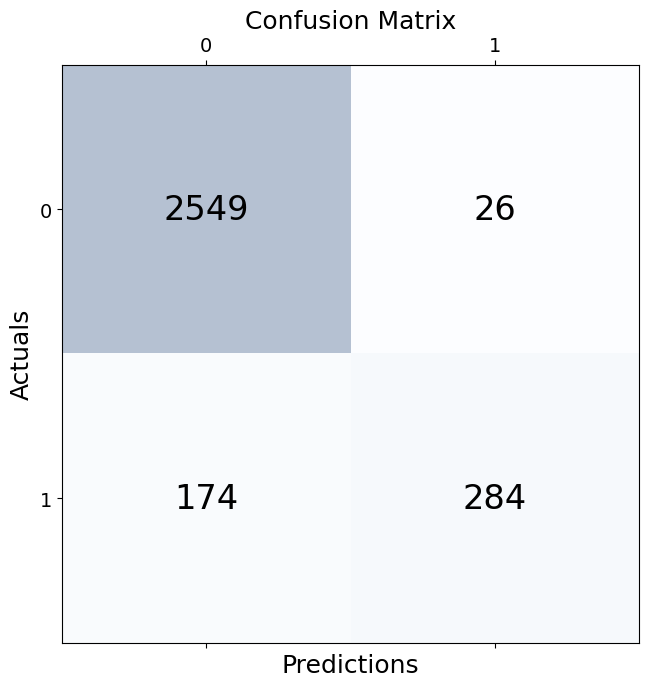

In [61]:
import seaborn as sn
import pandas as pd

tn_fp = [True if err < attack_threshold else False for err in benign_squared_errors]
tp_fn = [True if err > attack_threshold else False for err in attack_squared_errors]

tn = sum(tn_fp)
tp = sum(tp_fn)
fp = len(tn_fp) - tn
fn = len(tp_fn) - tp

# Display the confusion matrix
conf_matrix = np.array([[tn,fp],[fn,tp]])

fig, ax = plt.subplots(figsize=(7.5, 7.5))
ax.matshow(conf_matrix, cmap=plt.cm.Blues, alpha=0.3)
for i in range(conf_matrix.shape[0]):
    for j in range(conf_matrix.shape[1]):
        ax.text(x=j, y=i,s=conf_matrix[i, j], va='center', ha='center', size='xx-large')
 
plt.xlabel('Predictions', fontsize=18)
plt.ylabel('Actuals', fontsize=18)
plt.title('Confusion Matrix', fontsize=18)
plt.show()

In [62]:
accuracy = (tp+tn)/(tp+tn+fp+fn)
tpr = tp/(tp+fn) # recall
ppv = tp/(tp+fp) # precision
fpr = fp/(fp+tn) # false positive rate
fnr = fn/(fn+tp) # false negative rate
f1_score = 2*(tpr*ppv)/(tpr+ppv)


print ("Accuracy: ", accuracy)
print ("F1 Score: ", f1_score)
print ("FPR: ", fpr)
print ("FNR: ", fnr)

Accuracy:  0.9340586877678866
F1 Score:  0.7395833333333333
FPR:  0.010097087378640776
FNR:  0.3799126637554585
